In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("compas-scores-two-years.csv")

In [2]:
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
df = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].reset_index(drop=True)

features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "c_charge_degree", "sex", "race"]
target = "two_year_recid"

df = df[features + [target, "decile_score", "score_text", "age_cat"]]
df.head()

,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,sex,race,two_year_recid,decile_score,score_text,age_cat
0,69,0,0,0,0,F,Male,Other,0,1,Low,Greater than 45
1,34,0,0,0,0,F,Male,African-American,1,3,Low,25 - 45
2,24,4,0,0,1,F,Male,African-American,1,4,Low,Less than 25
3,44,0,0,0,0,M,Male,Other,0,1,Low,25 - 45
4,41,14,0,0,0,F,Male,Caucasian,1,6,Medium,25 - 45


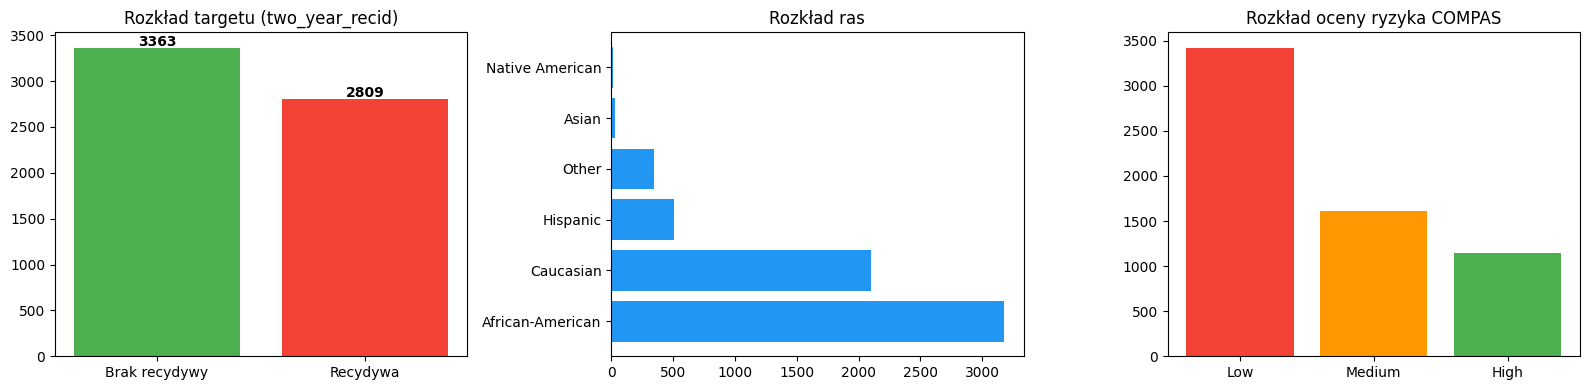

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df[target].value_counts()
axes[0].bar(["Brak recydywy", "Recydywa"], counts.values, color=["#4CAF50", "#F44336"])
axes[0].set_title("Rozkład targetu (two_year_recid)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

race_counts = df["race"].value_counts()
axes[1].barh(race_counts.index, race_counts.values, color="#2196F3")
axes[1].set_title("Rozkład ras")

score_counts = df["score_text"].value_counts()
axes[2].bar(score_counts.index, score_counts.values, color=["#F44336", "#FF9800", "#4CAF50"])
axes[2].set_title("Rozkład oceny ryzyka COMPAS")

plt.tight_layout()
plt.show()

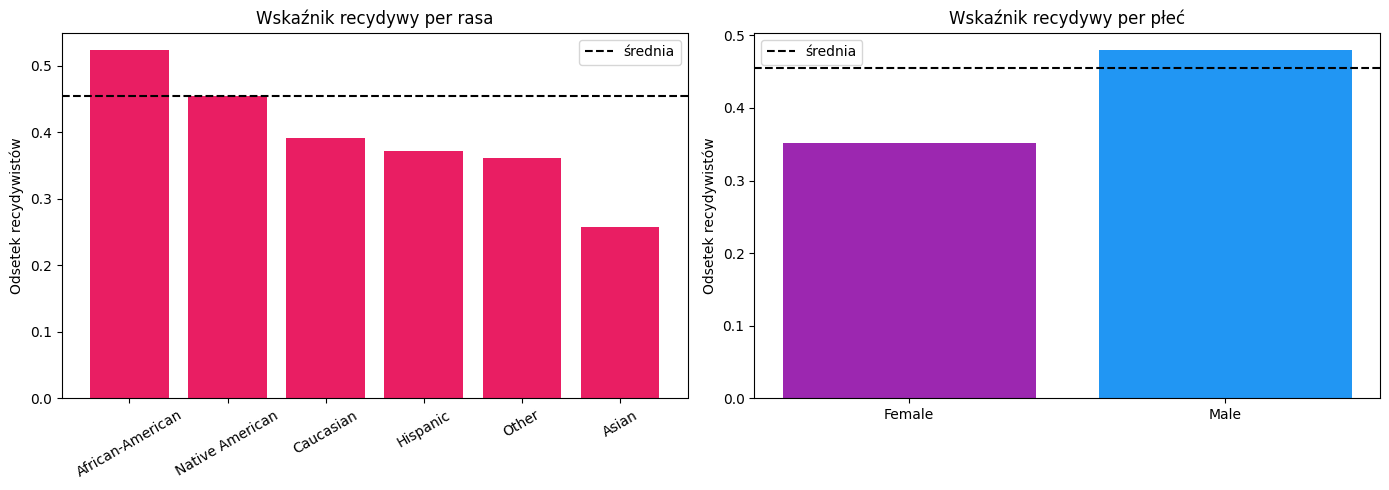

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_recid = df.groupby("race")[target].mean().sort_values(ascending=False)
axes[0].bar(race_recid.index, race_recid.values, color="#E91E63")
axes[0].set_title("Wskaźnik recydywy per rasa")
axes[0].set_ylabel("Odsetek recydywistów")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(df[target].mean(), color="black", linestyle="--", label="średnia")
axes[0].legend()

sex_recid = df.groupby("sex")[target].mean()
axes[1].bar(sex_recid.index, sex_recid.values, color=["#9C27B0", "#2196F3"])
axes[1].set_title("Wskaźnik recydywy per płeć")
axes[1].set_ylabel("Odsetek recydywistów")
axes[1].axhline(df[target].mean(), color="black", linestyle="--", label="średnia")
axes[1].legend()

plt.tight_layout()
plt.show()

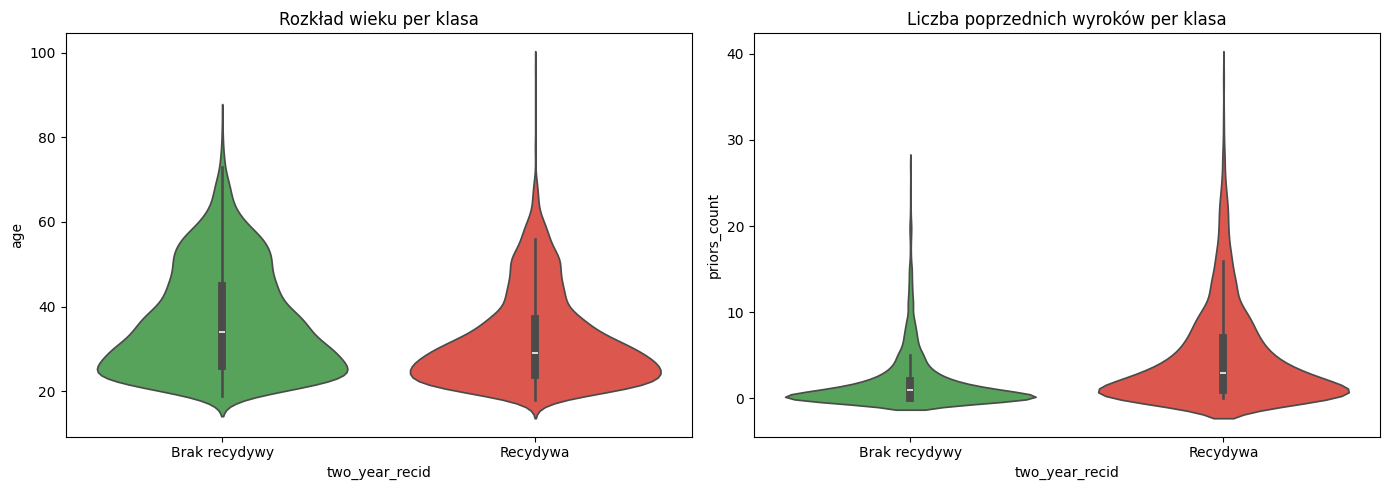

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x=target, y="age", hue=target, ax=axes[0],
               palette=["#4CAF50", "#F44336"], legend=False)
axes[0].set_title("Rozkład wieku per klasa")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Brak recydywy", "Recydywa"])

sns.violinplot(data=df, x=target, y="priors_count", hue=target, ax=axes[1],
               palette=["#4CAF50", "#F44336"], legend=False)
axes[1].set_title("Liczba poprzednich wyroków per klasa")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Brak recydywy", "Recydywa"])

plt.tight_layout()
plt.show()

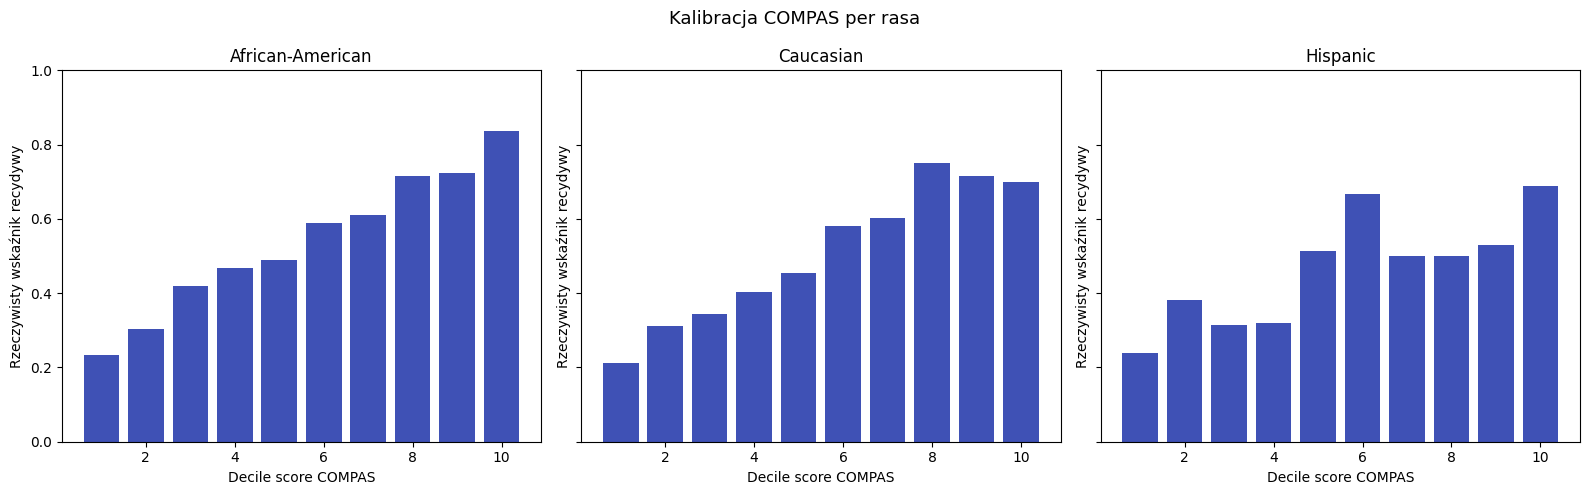

In [7]:
top_races = ["African-American", "Caucasian", "Hispanic"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, race in zip(axes, top_races):
    sub = df[df["race"] == race]
    recid_rate = sub.groupby("decile_score")[target].mean()
    ax.bar(recid_rate.index, recid_rate.values, color="#3F51B5")
    ax.set_title(race)
    ax.set_xlabel("Decile score COMPAS")
    ax.set_ylabel("Rzeczywisty wskaźnik recydywy")
    ax.set_ylim(0, 1)

plt.suptitle("Kalibracja COMPAS per rasa", fontsize=13)
plt.tight_layout()
plt.show()

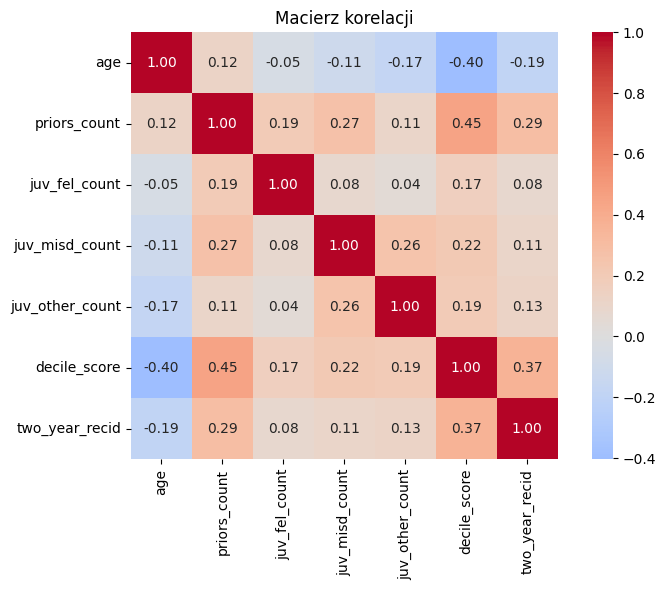

In [8]:
num_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count", "decile_score", target]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Macierz korelacji")
plt.tight_layout()
plt.show()

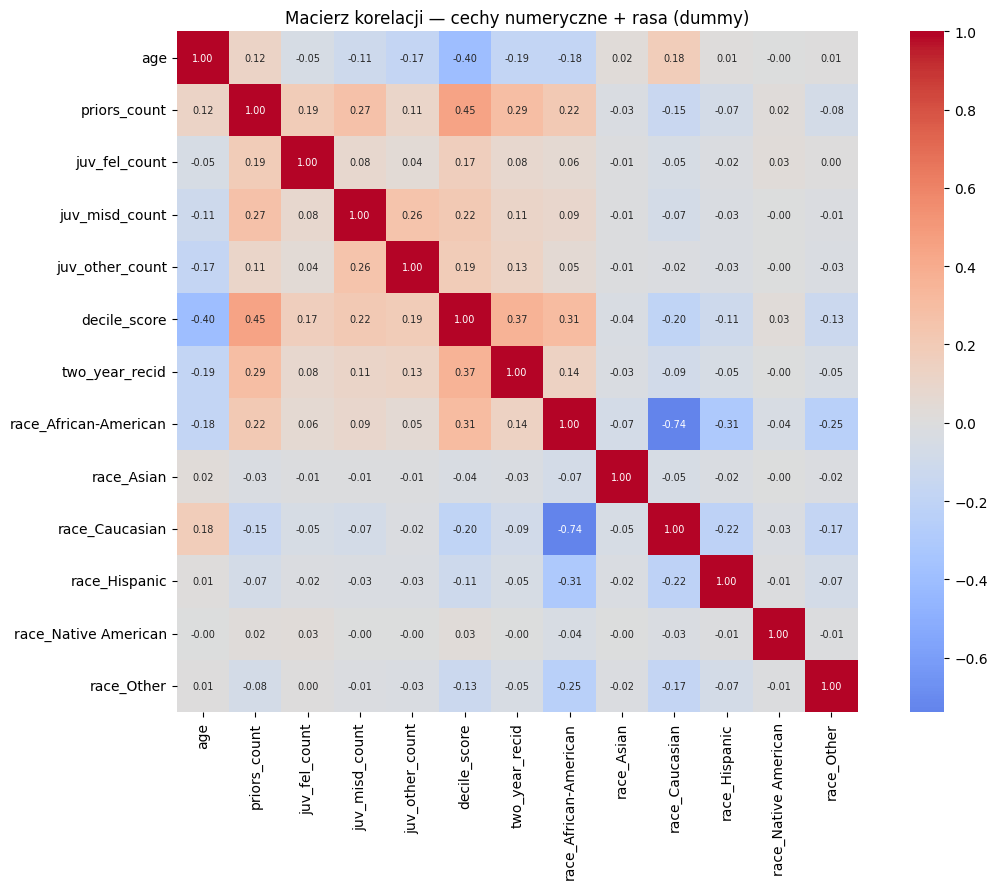

In [9]:
df_corr_race = pd.get_dummies(df[num_cols + ["race"]], columns=["race"])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_corr_race.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, annot_kws={"size": 7})
ax.set_title("Macierz korelacji — cechy numeryczne + rasa (dummy)")
plt.tight_layout()
plt.show()


- priors_count koreluje z race_African-American dodatnio i ujemnie z race_Caucasian — to mechanizm przez ktory rasa wplywa posrednio na wynik modelu mimo ze nie wchodzi wprost do cech
- decile_score (wynik COMPAS) rowniez wykazuje roznice miedzy grupami rasowymi, co potwierdza ze bias jest zakorzeniony w danych historycznych

In [10]:
le_sex = LabelEncoder()
le_charge = LabelEncoder()

df_model = df.copy()
df_model["sex"] = le_sex.fit_transform(df["sex"])
df_model["c_charge_degree"] = le_charge.fit_transform(df["c_charge_degree"])
df_model = pd.get_dummies(df_model, columns=["race", "age_cat"])

feature_cols = [c for c in df_model.columns if c not in [target, "decile_score", "score_text"]]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"Wymiary: X={X.shape}, pozytywnych: {y.mean():.1%}")

Wymiary: X=(6172, 16), pozytywnych: 45.5%


___

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

glass = fetch_openml(name="glass", version=1, as_frame=True)
X_glass = glass.data.values
y_glass = LabelEncoder().fit_transform(glass.target)

print("Braki danych Glass:")
print(glass.data.isnull().sum())

_glass_cv = StratifiedKFold(5, shuffle=True, random_state=42)

glass_models = {
    "Random Forest": Pipeline([("scaler", StandardScaler()),
                                ("clf", RandomForestClassifier(n_estimators=100))]),
    "AdaBoost":      Pipeline([("scaler", StandardScaler()),
                                ("clf", AdaBoostClassifier(n_estimators=100))]),
    "XGBoost":       Pipeline([("scaler", StandardScaler()),
                                ("clf", XGBClassifier(n_estimators=100, verbosity=0, eval_metric="mlogloss"))]),
}

_scoring_glass = {
    "accuracy":  "accuracy",
    "precision": "precision_macro",
    "recall":    "recall_macro",
    "f1":        "f1_macro",
}

results_glass_raw = {}
for name, pipeline in glass_models.items():
    cv_res = cross_validate(pipeline, X_glass, y_glass, cv=_glass_cv,
                            scoring=_scoring_glass, return_train_score=True)
    results_glass_raw[name] = cv_res

import pandas as pd
rows = {}
for name, cv_res in results_glass_raw.items():
    row = {}
    for m in _scoring_glass:
        row[f"train_{m}_mean"] = cv_res[f"train_{m}"].mean()
        row[f"train_{m}_std"]  = cv_res[f"train_{m}"].std()
        row[f"test_{m}_mean"]  = cv_res[f"test_{m}"].mean()
        row[f"test_{m}_std"]   = cv_res[f"test_{m}"].std()
    rows[name] = row

results_df_glass = pd.DataFrame(rows).T
print(results_df_glass[["test_f1_mean","test_f1_std","train_f1_mean","train_f1_std"]])


Braki danych Glass:
RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64
               test_f1_mean  test_f1_std  train_f1_mean  train_f1_std
Random Forest      0.741952     0.087768       1.000000      0.000000
AdaBoost           0.437728     0.047770       0.544001      0.061855
XGBoost            0.747785     0.048322       1.000000      0.000000


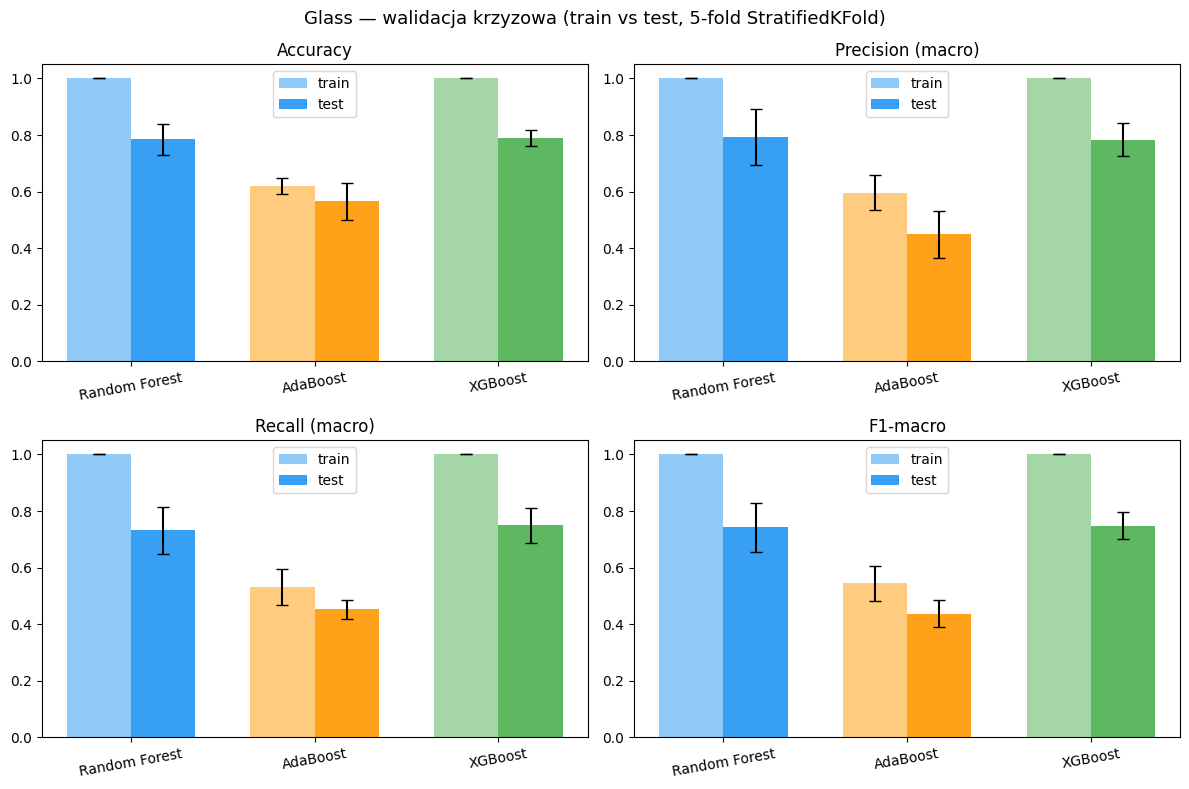

In [12]:
import numpy as np

_colors_glass = {"Random Forest": "#2196F3", "AdaBoost": "#FF9800", "XGBoost": "#4CAF50"}
_metrics_glass = ["accuracy", "precision", "recall", "f1"]
_metric_labels = {"accuracy": "Accuracy", "precision": "Precision (macro)",
                  "recall": "Recall (macro)", "f1": "F1-macro"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

model_names = list(results_df_glass.index)
x = np.arange(len(model_names))
width = 0.35

for ax, m in zip(axes, _metrics_glass):
    train_means = results_df_glass[f"train_{m}_mean"].values
    train_stds  = results_df_glass[f"train_{m}_std"].values
    test_means  = results_df_glass[f"test_{m}_mean"].values
    test_stds   = results_df_glass[f"test_{m}_std"].values

    bars_train = ax.bar(x - width/2, train_means, width, yerr=train_stds,
                        label="train", alpha=0.5, capsize=4,
                        color=[_colors_glass[n] for n in model_names])
    bars_test  = ax.bar(x + width/2, test_means, width, yerr=test_stds,
                        label="test", alpha=0.9, capsize=4,
                        color=[_colors_glass[n] for n in model_names])
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10)
    ax.set_title(_metric_labels[m])
    ax.set_ylim(0, 1.05)
    ax.legend(["train", "test"])

plt.suptitle("Glass — walidacja krzyzowa (train vs test, 5-fold StratifiedKFold)", fontsize=13)
plt.tight_layout()
plt.show()


- xgboost i rf osiagaja podobny test f1-macro, ale roznica train/test u rf jest wieksza — wskazuje na wyzszy overfitting przy braku regularyzacji
- adaboost ma mniejszy spread std miedzy foldami niz rf — bardziej stabilny ale slabszy szczytowo
- pipeline ze StandardScaler nie zmienia wynikow dla drzew decyzyjnych ale ujednolica kod i przygotowuje do porownania z metodami wrazliwymi na skale


___

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import itertools

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
from sklearn.model_selection import cross_validate, StratifiedKFold

def cv_metrics(estimator, X, y, cv):
    scoring = {
        "accuracy":  "accuracy",
        "precision": "precision",
        "recall":    "recall",
        "f1":        "f1",
        "roc_auc":   "roc_auc",
    }
    s = cross_validate(estimator, X, y, cv=cv, scoring=scoring, return_train_score=True)
    result = {}
    for m in scoring:
        for split in ["train", "test"]:
            result[f"{m}_{split}"]     = s[f"{split}_{m}"].mean()
            result[f"{m}_{split}_std"] = s[f"{split}_{m}"].std()
    return result


def plot_param_sweep(results_dict, param_name, model_name, color, param_vals):
    df_sweep = pd.DataFrame(results_dict).T
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
    labels = [str(v) for v in param_vals]
    for ax, m in zip(axes, metrics):
        ax.errorbar(labels, df_sweep[f"{m}_train"], yerr=df_sweep[f"{m}_train_std"],
                    marker="o", color=color, linestyle="--", label="train", alpha=0.6)
        ax.errorbar(labels, df_sweep[f"{m}_test"],  yerr=df_sweep[f"{m}_test_std"],
                    marker="o", color=color, label="test")
        ax.set_title(m)
        ax.set_ylim(0, 1.05)
        ax.legend()
    plt.suptitle(f"{model_name} — {param_name}")
    plt.tight_layout()
    plt.show()


_cv5 = StratifiedKFold(5, shuffle=True, random_state=42)


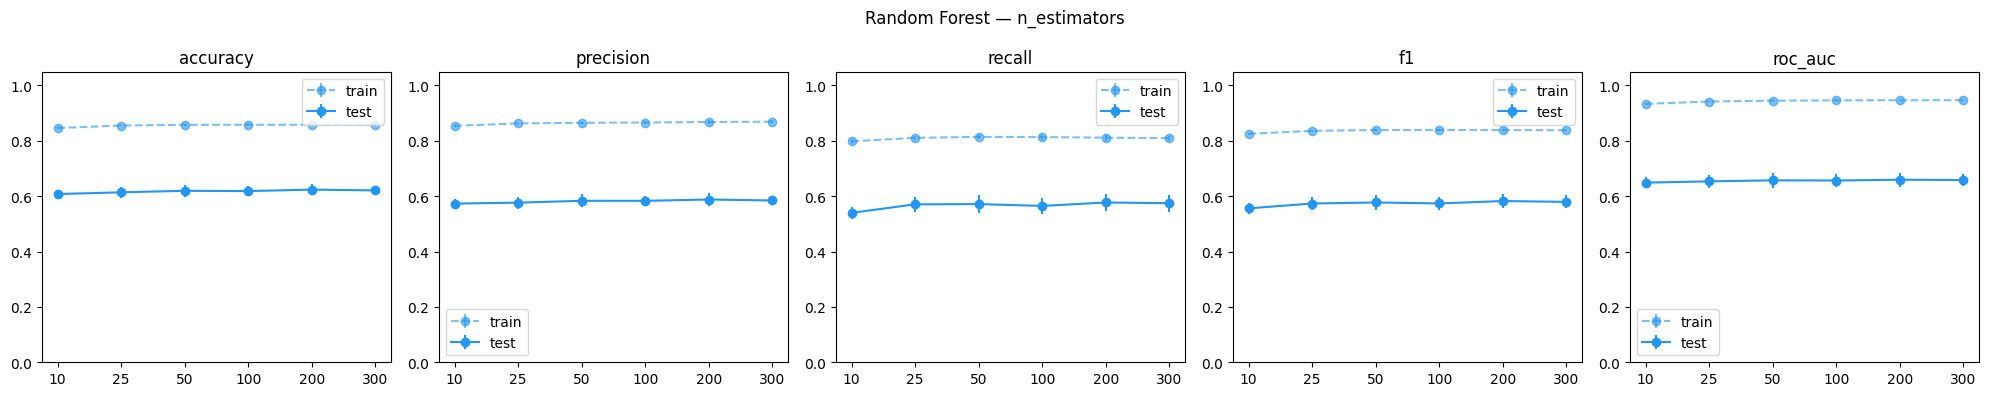

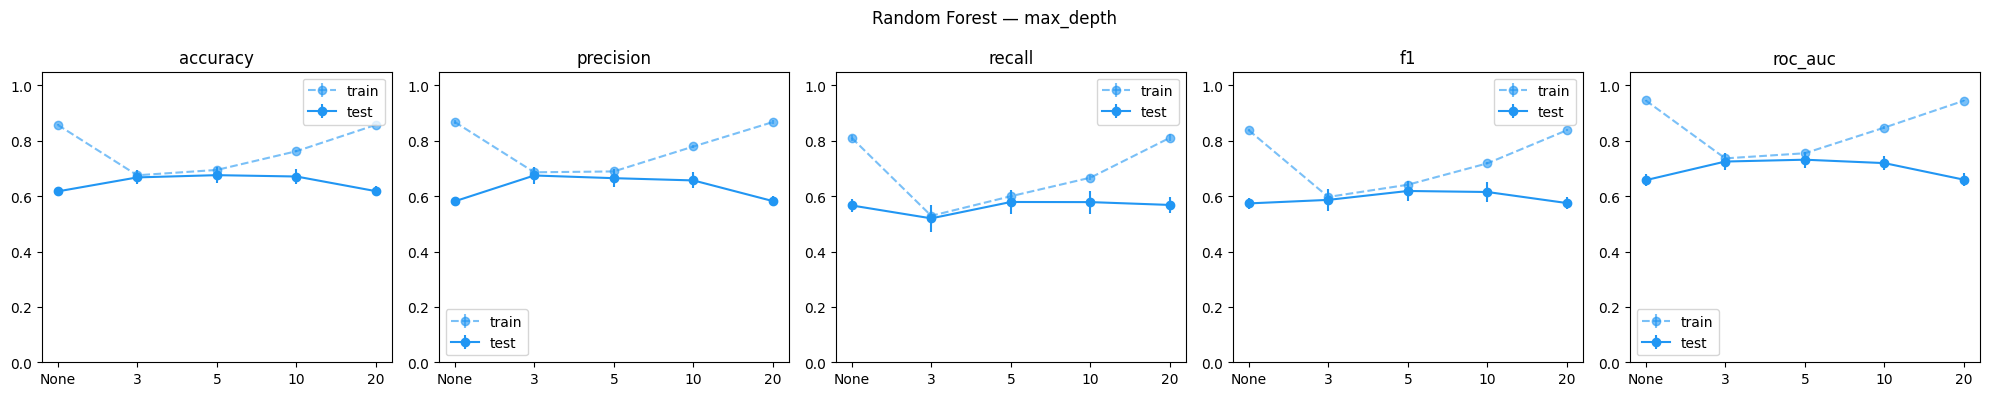

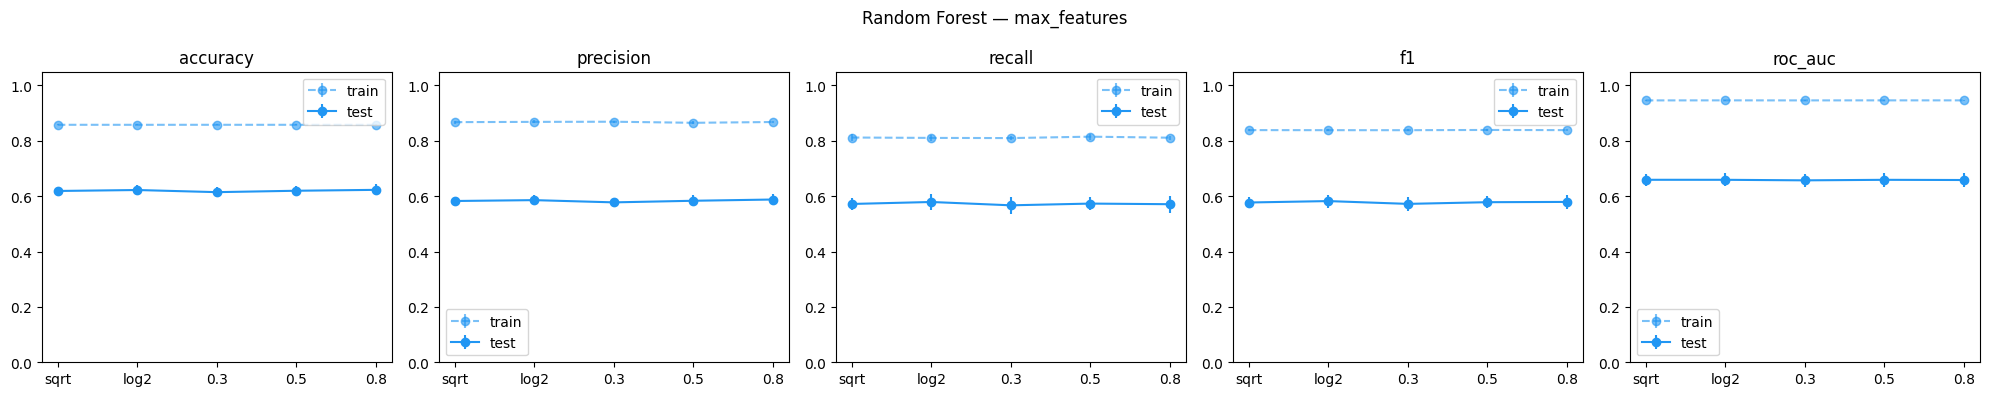

In [15]:
n_estimators_vals = [10, 25, 50, 100, 200, 300]
max_depth_vals    = [None, 3, 5, 10, 20]
max_features_vals = ["sqrt", "log2", 0.3, 0.5, 0.8]

rf_nest_cv = {n: cv_metrics(RandomForestClassifier(n_estimators=n), X_train, y_train, _cv5)
              for n in n_estimators_vals}
plot_param_sweep(rf_nest_cv, "n_estimators", "Random Forest", "#2196F3", n_estimators_vals)

rf_depth_cv = {d: cv_metrics(RandomForestClassifier(n_estimators=100, max_depth=d), X_train, y_train, _cv5)
               for d in max_depth_vals}
plot_param_sweep(rf_depth_cv, "max_depth", "Random Forest", "#2196F3", max_depth_vals)

rf_feat_cv = {f: cv_metrics(RandomForestClassifier(n_estimators=100, max_features=f), X_train, y_train, _cv5)
              for f in max_features_vals}
plot_param_sweep(rf_feat_cv, "max_features", "Random Forest", "#2196F3", max_features_vals)


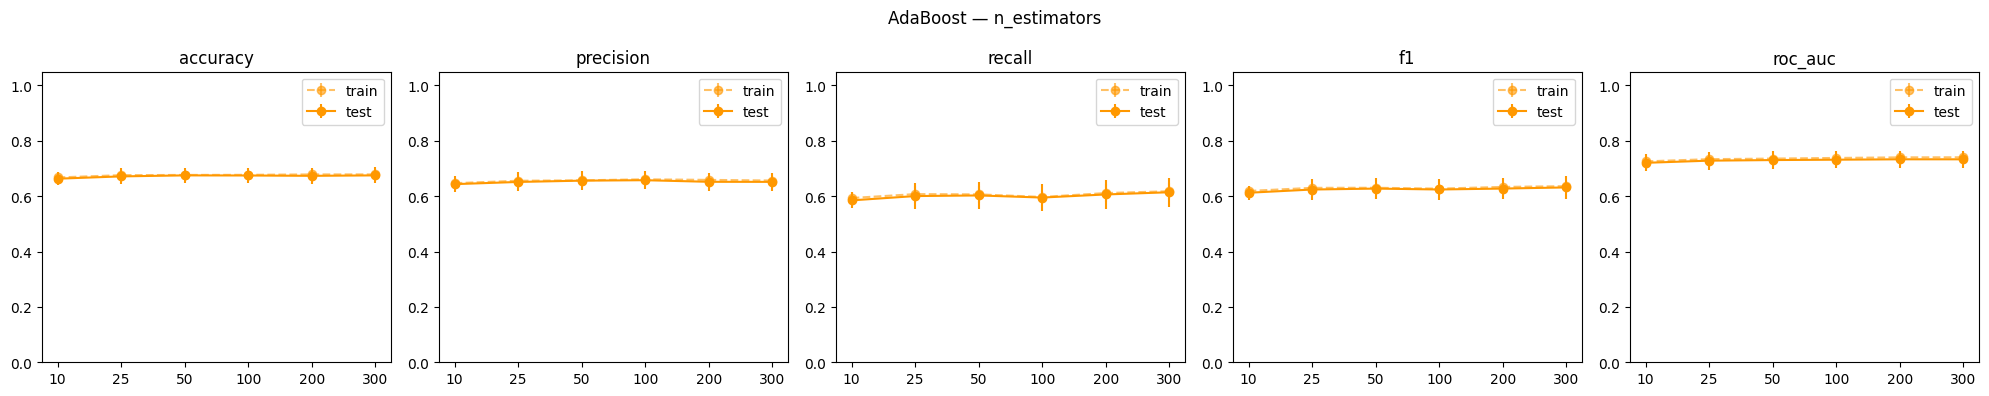

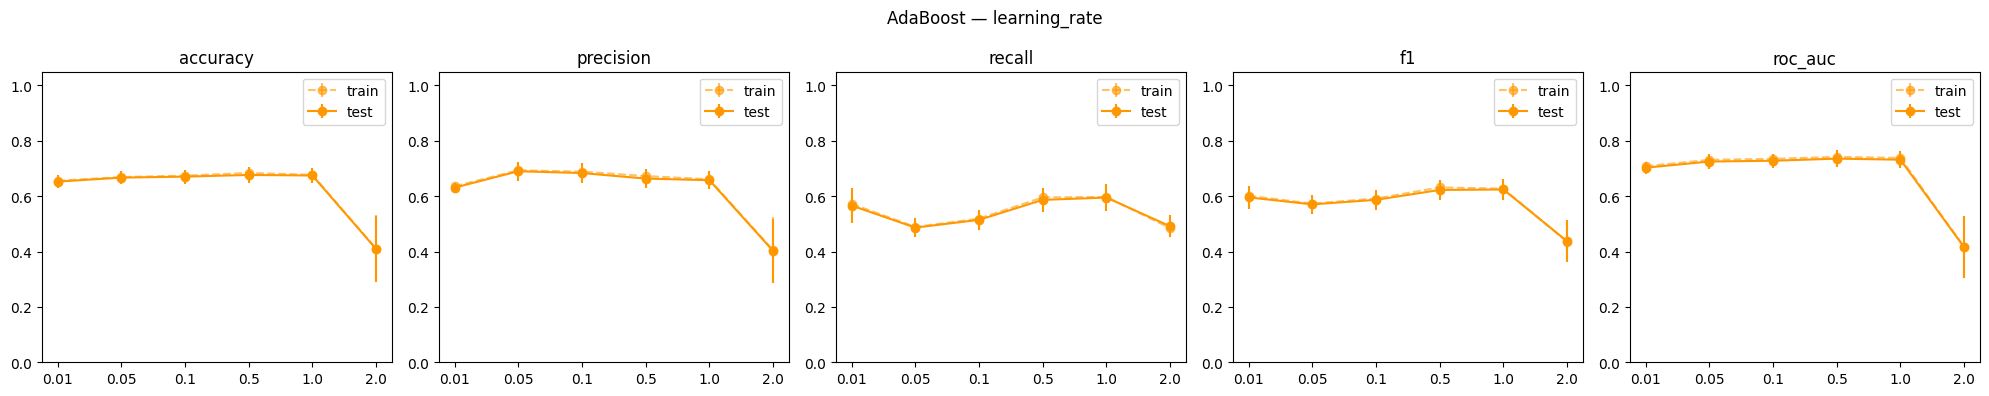

In [16]:
lr_vals = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

ab_nest_cv = {n: cv_metrics(AdaBoostClassifier(n_estimators=n), X_train, y_train, _cv5)
              for n in n_estimators_vals}
plot_param_sweep(ab_nest_cv, "n_estimators", "AdaBoost", "#FF9800", n_estimators_vals)

ab_lr_cv = {lr: cv_metrics(AdaBoostClassifier(n_estimators=100, learning_rate=lr), X_train, y_train, _cv5)
            for lr in lr_vals}
plot_param_sweep(ab_lr_cv, "learning_rate", "AdaBoost", "#FF9800", lr_vals)


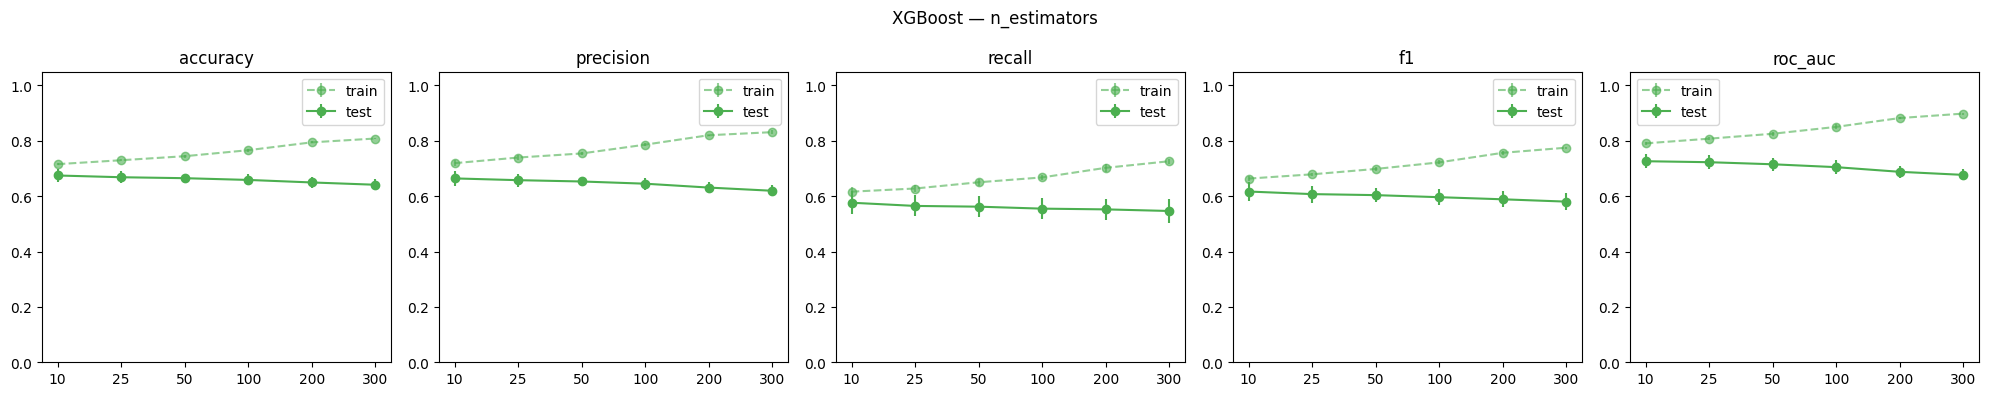

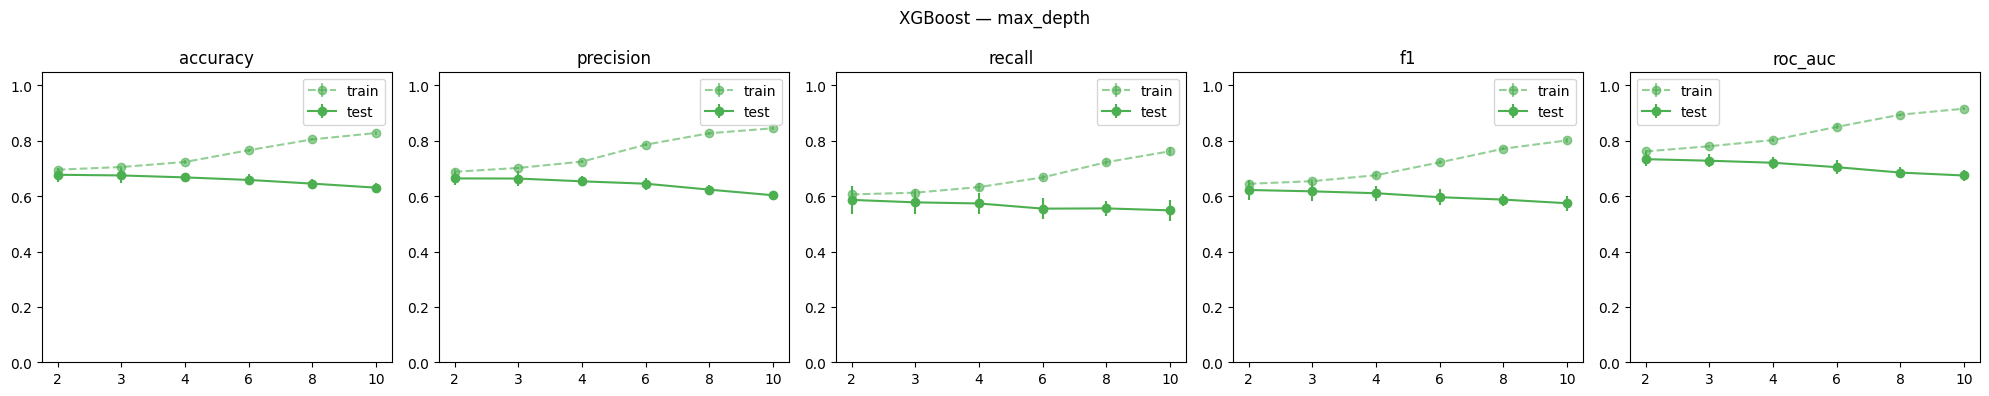

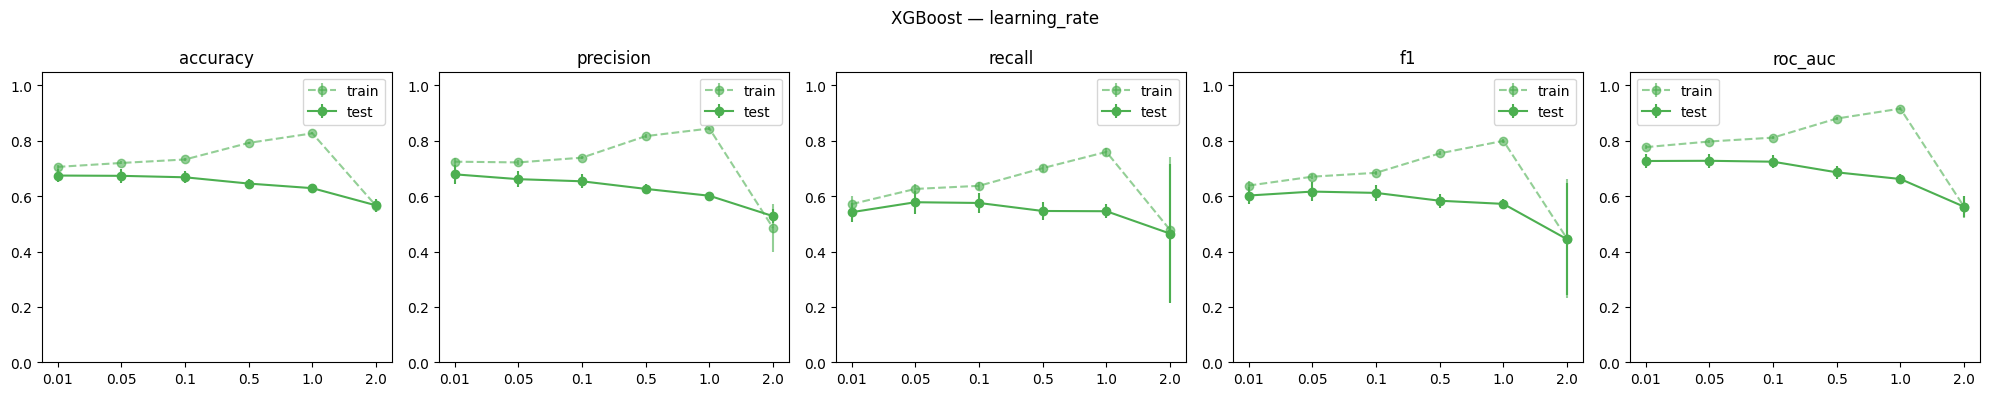

In [17]:
depth_vals = [2, 3, 4, 6, 8, 10]

xgb_nest_cv = {n: cv_metrics(XGBClassifier(n_estimators=n, verbosity=0, eval_metric="logloss"),
                              X_train, y_train, _cv5)
               for n in n_estimators_vals}
plot_param_sweep(xgb_nest_cv, "n_estimators", "XGBoost", "#4CAF50", n_estimators_vals)

xgb_depth_cv = {d: cv_metrics(XGBClassifier(n_estimators=100, max_depth=d, verbosity=0, eval_metric="logloss"),
                               X_train, y_train, _cv5)
                for d in depth_vals}
plot_param_sweep(xgb_depth_cv, "max_depth", "XGBoost", "#4CAF50", depth_vals)

xgb_lr_cv = {lr: cv_metrics(XGBClassifier(n_estimators=100, learning_rate=lr, verbosity=0, eval_metric="logloss"),
                             X_train, y_train, _cv5)
             for lr in lr_vals}
plot_param_sweep(xgb_lr_cv, "learning_rate", "XGBoost", "#4CAF50", lr_vals)


- errorbary std miedzy foldami sa stosunkowo waskie dla wszystkich modeli — wyniki sa stabilne
- gap train/test u rf rosnie z glebokoscia drzew (max_depth=None to max overfitting)
- xgboost z niskim learning_rate i wiecej estymatorami daje mniejsza wariancje niz duzy LR z mala liczba drzew
- adaboost jest wrazliwy na LR — powyzej 1.0 test-f1 wyraznie spada


___


=== RF top 5 ===
                                                     f1_test  f1_test_std  \
{'n_estimators': 200, 'max_depth': 5, 'min_samp...  0.625406     0.034963   
{'n_estimators': 100, 'max_depth': 10, 'min_sam...  0.624692     0.033473   
{'n_estimators': 200, 'max_depth': 10, 'min_sam...  0.622083     0.032918   
{'n_estimators': 100, 'max_depth': 5, 'min_samp...  0.620784     0.036995   
{'n_estimators': 100, 'max_depth': 5, 'min_samp...  0.619705     0.032879   

                                                    roc_auc_test  
{'n_estimators': 200, 'max_depth': 5, 'min_samp...      0.733031  
{'n_estimators': 100, 'max_depth': 10, 'min_sam...      0.727805  
{'n_estimators': 200, 'max_depth': 10, 'min_sam...      0.728185  
{'n_estimators': 100, 'max_depth': 5, 'min_samp...      0.731992  
{'n_estimators': 100, 'max_depth': 5, 'min_samp...      0.732741  

=== AdaBoost top 5 ===
                                              f1_test  f1_test_std  \
{'n_estimators': 200, 'l

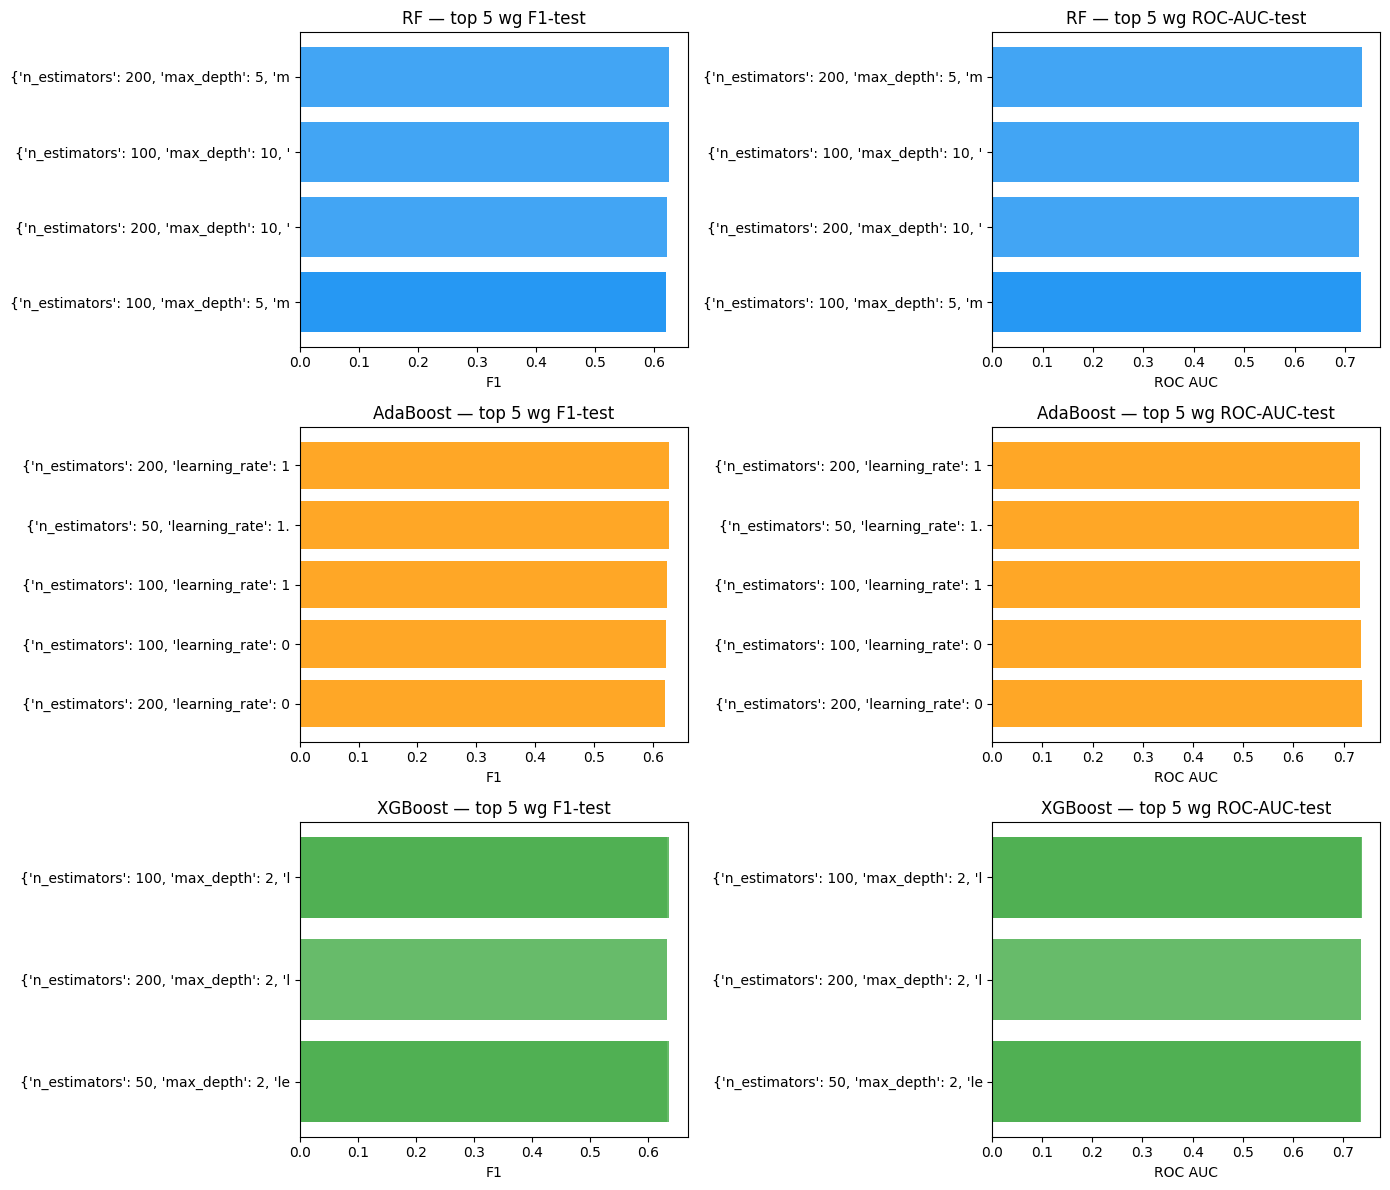

In [18]:
from itertools import product as iproduct

def grid_search_cv(model_class, param_grid, fixed_params, X, y, cv):
    results = {}
    keys = list(param_grid.keys())
    for vals in iproduct(*param_grid.values()):
        params = dict(zip(keys, vals))
        m = model_class(**{**fixed_params, **params})
        results[str(params)] = cv_metrics(m, X, y, cv)
    return pd.DataFrame(results).T.sort_values("f1_test", ascending=False)


rf_grid = grid_search_cv(
    RandomForestClassifier,
    {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None], "min_samples_leaf": [1, 5]},
    {},
    X_train, y_train, _cv5,
)

ab_grid = grid_search_cv(
    AdaBoostClassifier,
    {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]},
    {},
    X_train, y_train, _cv5,
)

xgb_grid = grid_search_cv(
    XGBClassifier,
    {"n_estimators": [50, 100, 200], "max_depth": [2, 4, 6], "learning_rate": [0.05, 0.1, 0.3]},
    {"verbosity": 0, "eval_metric": "logloss"},
    X_train, y_train, _cv5,
)

print("=== RF top 5 ===")
print(rf_grid[["f1_test","f1_test_std","roc_auc_test"]].head())
print("\n=== AdaBoost top 5 ===")
print(ab_grid[["f1_test","f1_test_std","roc_auc_test"]].head())
print("\n=== XGBoost top 5 ===")
print(xgb_grid[["f1_test","f1_test_std","roc_auc_test"]].head())

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
_grid_colors = {"RF": "#2196F3", "AdaBoost": "#FF9800", "XGBoost": "#4CAF50"}

for row, (name, grid, color) in enumerate([
    ("RF", rf_grid, "#2196F3"),
    ("AdaBoost", ab_grid, "#FF9800"),
    ("XGBoost", xgb_grid, "#4CAF50"),
]):
    top5 = grid.head(5)
    labels = [s[:40] for s in top5.index]
    axes[row, 0].barh(labels[::-1], top5["f1_test"].values[::-1], color=color, alpha=0.85)
    axes[row, 0].set_title(f"{name} — top 5 wg F1-test")
    axes[row, 0].set_xlabel("F1")
    axes[row, 1].barh(labels[::-1], top5["roc_auc_test"].values[::-1], color=color, alpha=0.85)
    axes[row, 1].set_title(f"{name} — top 5 wg ROC-AUC-test")
    axes[row, 1].set_xlabel("ROC AUC")

plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay
import shap

def _parse_params(idx_str):
    import ast
    return ast.literal_eval(idx_str)

rf_best_params   = _parse_params(rf_grid.index[0])
ab_best_params   = _parse_params(ab_grid.index[0])
xgb_best_params  = _parse_params(xgb_grid.index[0])

best_models = {
    "Random Forest": RandomForestClassifier(**rf_best_params),
    "AdaBoost":      AdaBoostClassifier(**ab_best_params),
    "XGBoost":       XGBClassifier(**xgb_best_params, verbosity=0, eval_metric="logloss"),
}

for name, model in best_models.items():
    model.fit(X_train, y_train)

print("Najlepsze parametry:")
print(f"  RF:       {rf_best_params}")
print(f"  AdaBoost: {ab_best_params}")
print(f"  XGBoost:  {xgb_best_params}")


Najlepsze parametry:
  RF:       {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 1}
  AdaBoost: {'n_estimators': 200, 'learning_rate': 1.0}
  XGBoost:  {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1}


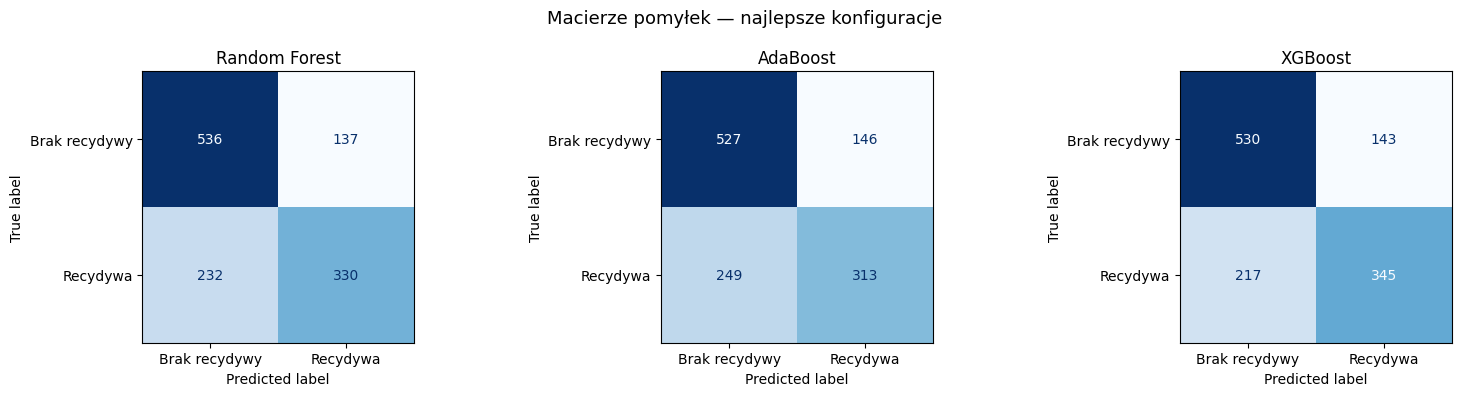

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test),
        display_labels=["Brak recydywy", "Recydywa"],
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)

plt.suptitle("Macierze pomyłek — najlepsze konfiguracje", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report

for name, m in best_models.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, m.predict(X_test),
                                 target_names=["Brak recydywy", "Recydywa"]))



=== Random Forest ===
               precision    recall  f1-score   support

Brak recydywy       0.70      0.80      0.74       673
     Recydywa       0.71      0.59      0.64       562

     accuracy                           0.70      1235
    macro avg       0.70      0.69      0.69      1235
 weighted avg       0.70      0.70      0.70      1235


=== AdaBoost ===
               precision    recall  f1-score   support

Brak recydywy       0.68      0.78      0.73       673
     Recydywa       0.68      0.56      0.61       562

     accuracy                           0.68      1235
    macro avg       0.68      0.67      0.67      1235
 weighted avg       0.68      0.68      0.68      1235


=== XGBoost ===
               precision    recall  f1-score   support

Brak recydywy       0.71      0.79      0.75       673
     Recydywa       0.71      0.61      0.66       562

     accuracy                           0.71      1235
    macro avg       0.71      0.70      0.70      1235

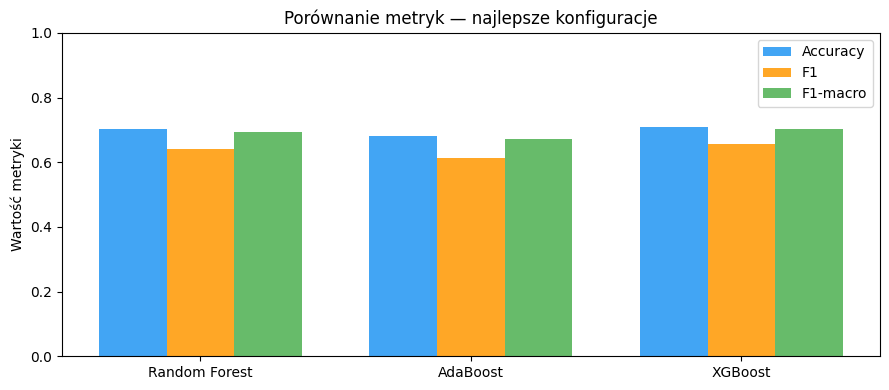

In [22]:
metrics = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    metrics[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "F1-macro":  f1_score(y_test, y_pred, average="macro"),
    }

metrics_df = pd.DataFrame(metrics).T

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics_df))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50"]

for i, col in enumerate(metrics_df.columns):
    ax.bar(x + i * width, metrics_df[col], width, label=col, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df.index)
ax.set_ylabel("Wartość metryki")
ax.set_title("Porównanie metryk — najlepsze konfiguracje")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

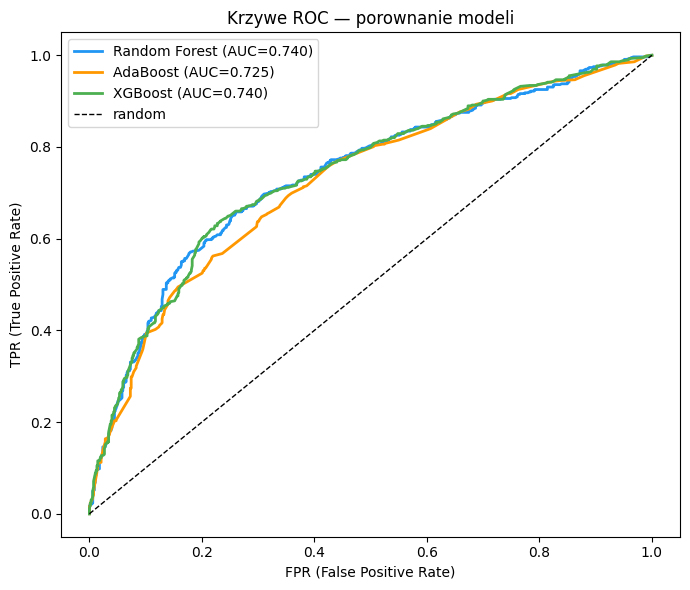

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

_colors_roc = {"Random Forest": "#2196F3", "AdaBoost": "#FF9800", "XGBoost": "#4CAF50"}

fig, ax = plt.subplots(figsize=(7, 6))
for name, m in best_models.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=_colors_roc[name], linewidth=2,
            label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="random", linewidth=1)
ax.set_xlabel("FPR (False Positive Rate)")
ax.set_ylabel("TPR (True Positive Rate)")
ax.set_title("Krzywe ROC — porownanie modeli")
ax.legend()
plt.tight_layout()
plt.show()


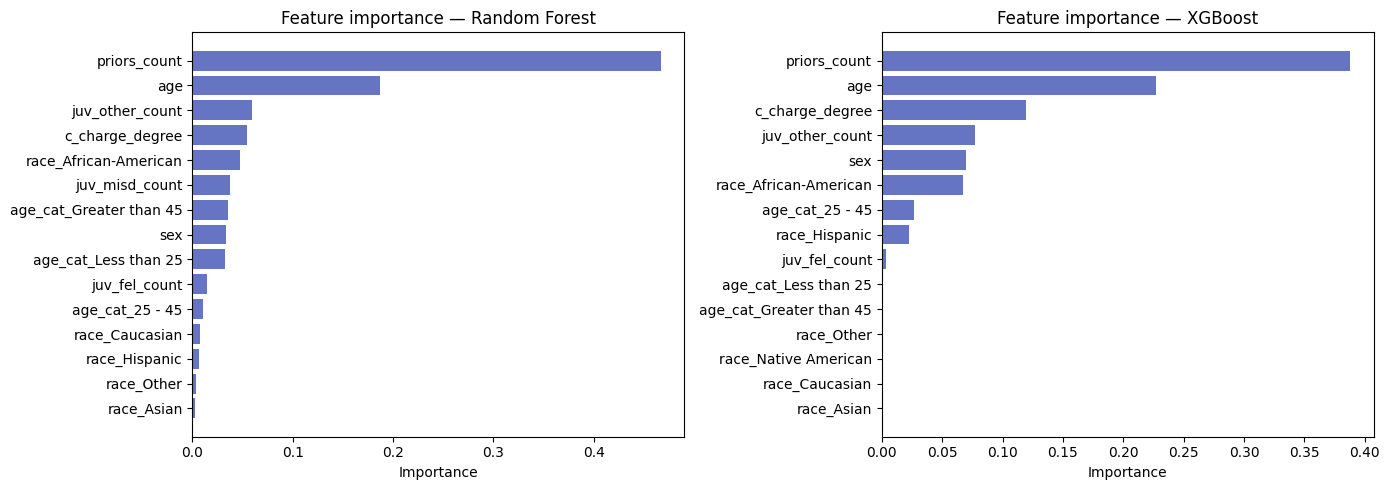

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, {k: v for k, v in best_models.items() if k != "AdaBoost"}.items()):
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color="#3F51B5", alpha=0.8)
    ax.set_title(f"Feature importance — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

PermutationExplainer explainer: 201it [00:26,  5.09it/s]                         


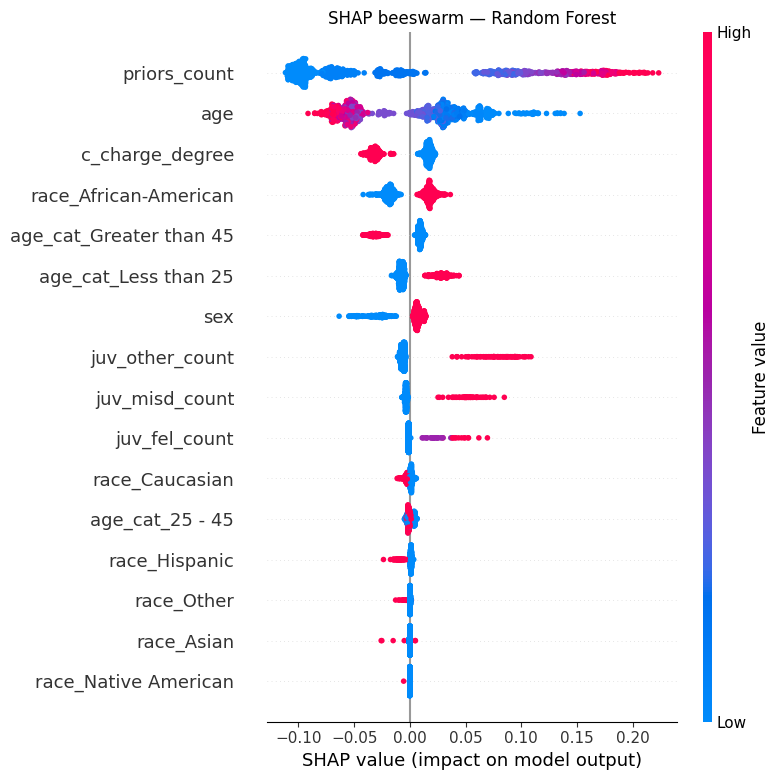

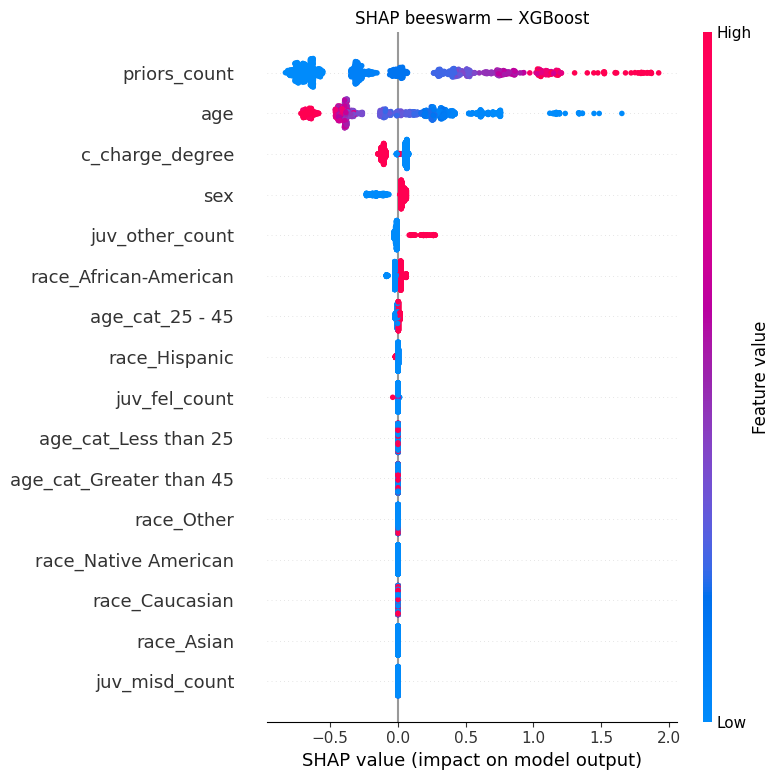

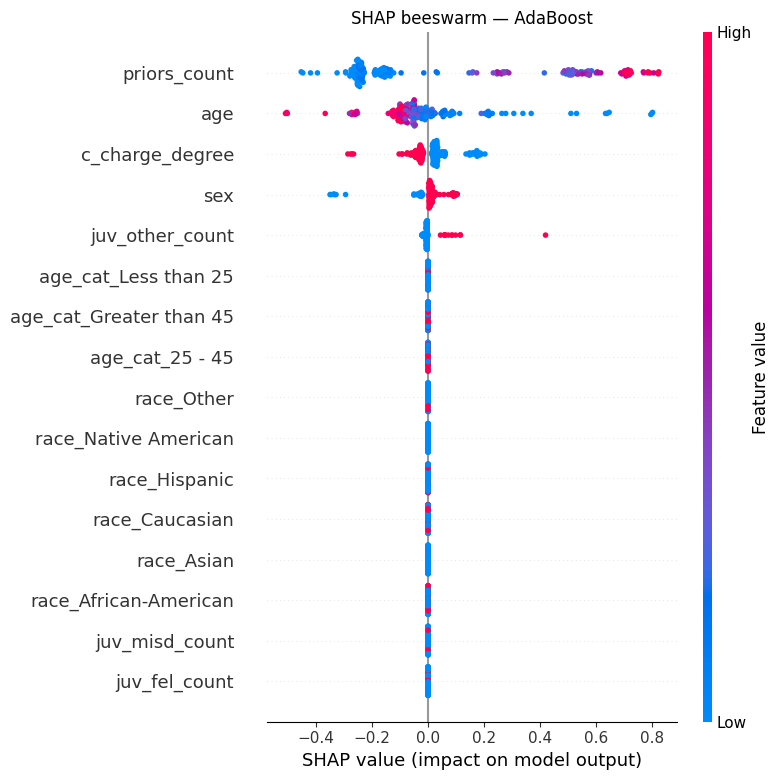

In [26]:
import shap


X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

_shap_bg = shap.sample(X_train_f, 100).astype(float)

_shap_explainers = {
    "Random Forest": shap.TreeExplainer(best_models["Random Forest"]),
    "XGBoost":       shap.TreeExplainer(best_models["XGBoost"]),
    "AdaBoost":      shap.PermutationExplainer(
                         best_models["AdaBoost"].predict,
                         _shap_bg),
}

_shap_vals = {}
for name, exp in _shap_explainers.items():
    X_shap = X_test_f[:200] if name == "AdaBoost" else X_test_f
    sv = exp(X_shap)
    # RF TreeExplainer dla klasyfikacji binarnej zwraca (n, features, 2) — bierzemy klase 1
    if hasattr(sv, "values") and sv.values.ndim == 3:
        sv = sv[..., 1]
    _shap_vals[name] = sv

for name, sv in _shap_vals.items():
    X_shap = X_test_f[:200] if name == "AdaBoost" else X_test_f
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv if isinstance(sv, np.ndarray) else sv.values,
                      X_shap, feature_names=feature_cols, show=False)
    plt.title(f"SHAP beeswarm — {name}")
    plt.tight_layout()
    plt.show()


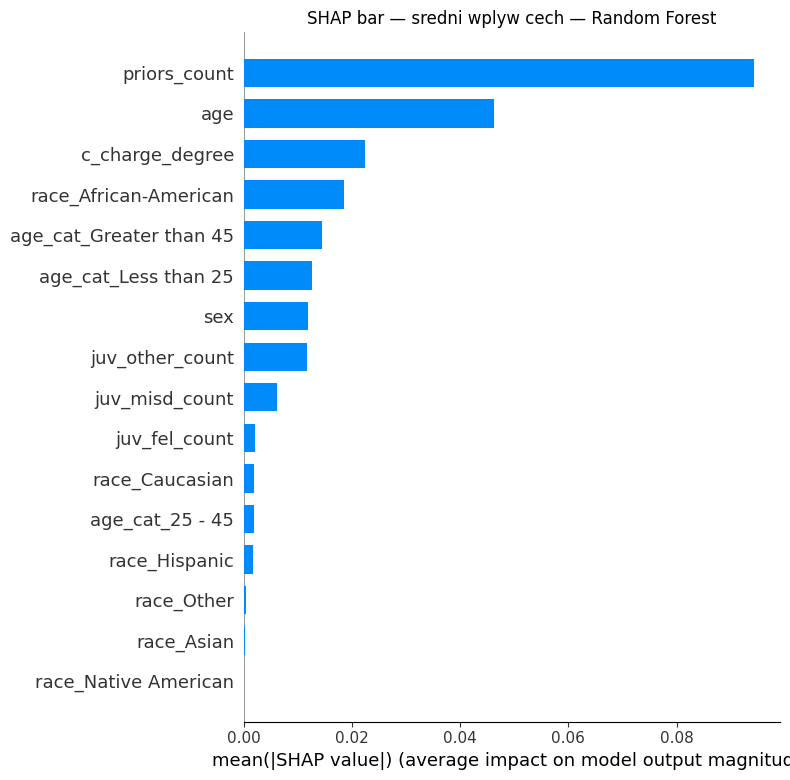

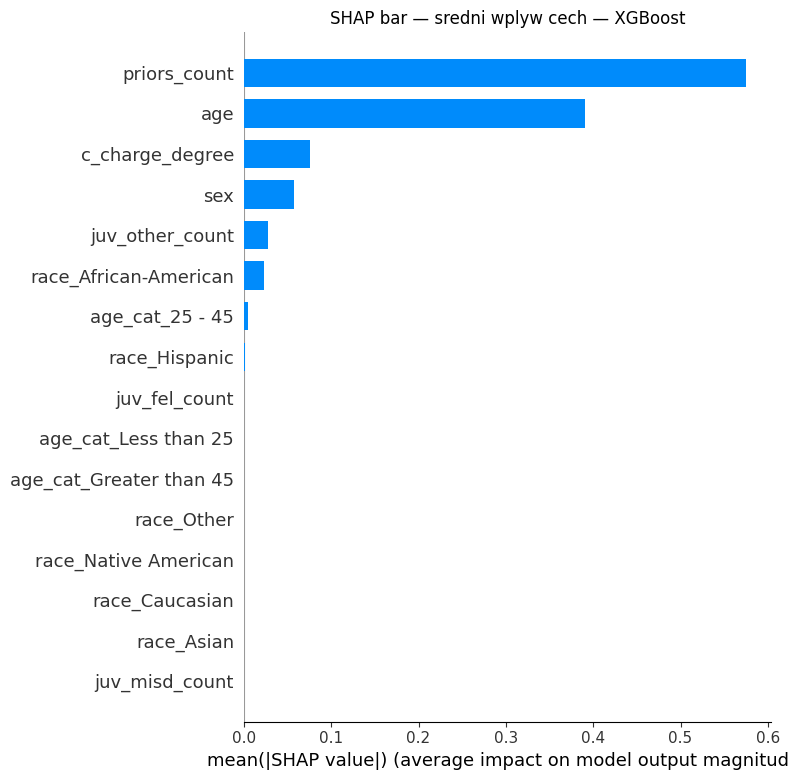

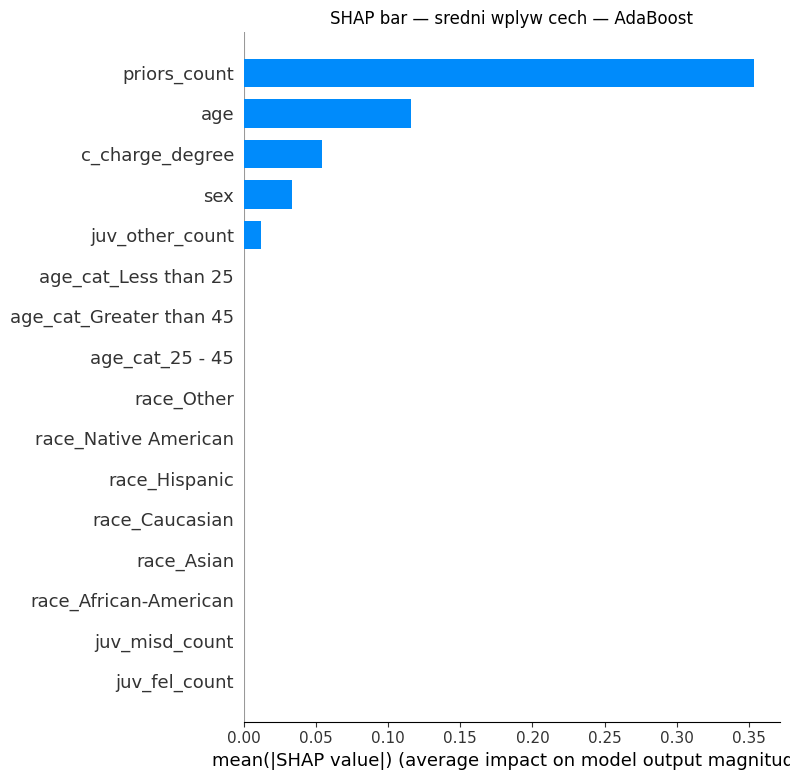

In [27]:
for name, sv in _shap_vals.items():
    X_shap = X_test_f[:200] if name == "AdaBoost" else X_test_f
    plt.figure(figsize=(10, 5))
    shap.summary_plot(sv if isinstance(sv, np.ndarray) else sv.values,
                      X_shap, feature_names=feature_cols,
                      plot_type="bar", show=False)
    plt.title(f"SHAP bar — sredni wplyw cech — {name}")
    plt.tight_layout()
    plt.show()


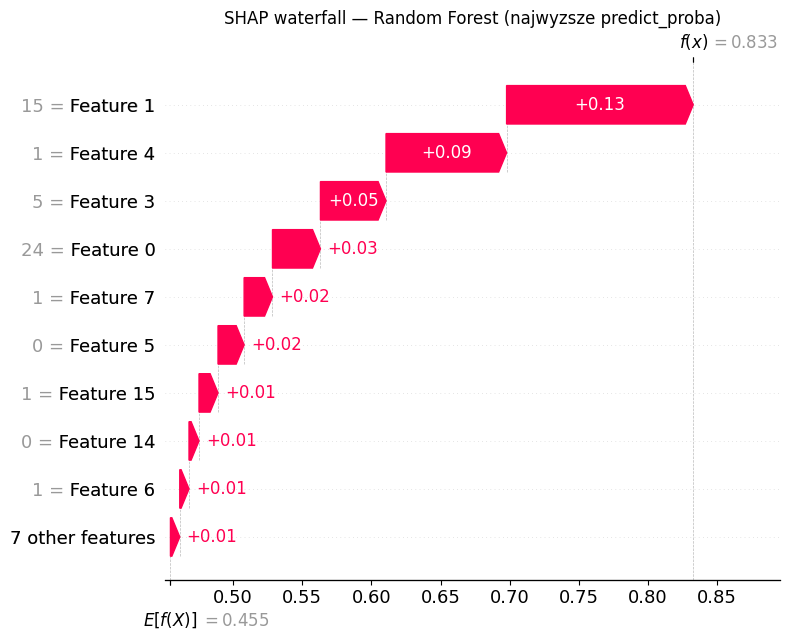

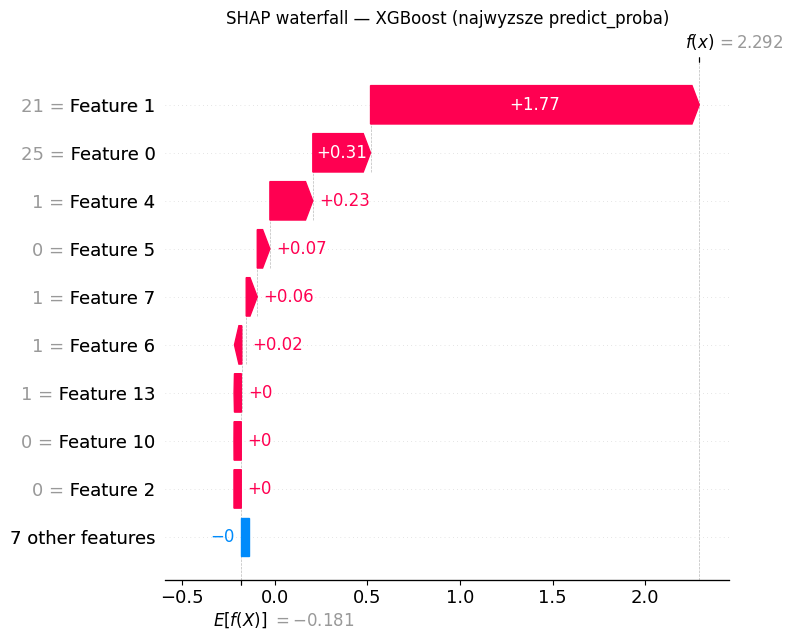

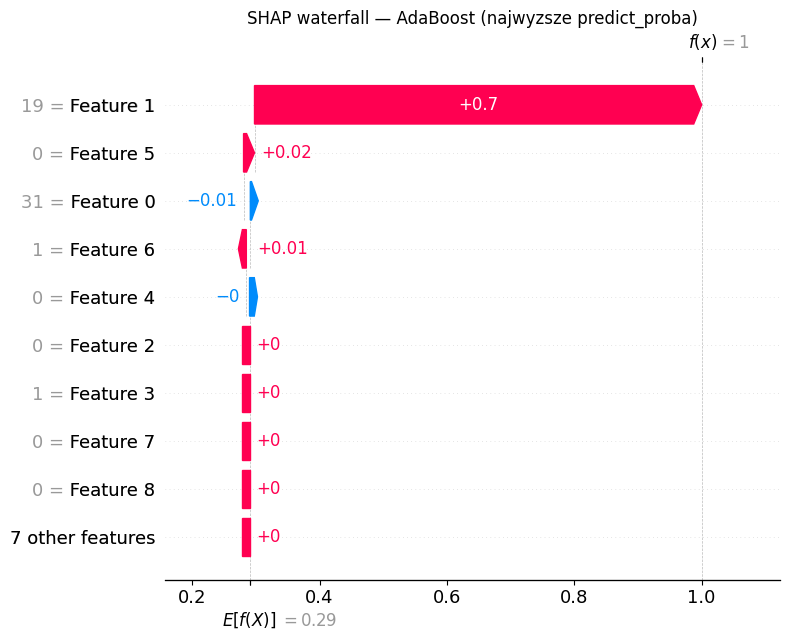

In [28]:
for name, sv in _shap_vals.items():
    X_shap = X_test_f[:200] if name == "AdaBoost" else X_test_f
    proba = best_models[name].predict_proba(X_shap)[:, 1]
    idx = int(np.argmax(proba))

    if isinstance(sv, np.ndarray):
        ev = _shap_explainers[name].expected_value
        if hasattr(ev, '__len__'):
            ev = ev[1]
        exp_obj = shap.Explanation(
            values=sv[idx],
            base_values=ev,
            data=X_shap[idx],
            feature_names=feature_cols,
        )
    else:
        exp_obj = sv[idx]

    shap.plots.waterfall(exp_obj, show=False)
    plt.title(f"SHAP waterfall — {name} (najwyzsze predict_proba)")
    plt.tight_layout()
    plt.show()


___

In [29]:
import fairlearn


from fairlearn.metrics import (
    demographic_parity_difference,
    equal_opportunity_difference,
    equalized_odds_difference,
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
)
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [30]:
def _get_fpr_fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp
    return {
        "TPR":      tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "FPR":      fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        "FNR":      fn / (tp + fn) if (tp + fn) > 0 else 0.0,
        "Accuracy": (tp + tn) / total,
    }


def _set_race_all(X, race_col_indices, target_race):
    X_new = X.copy()
    for col_idx in race_col_indices.values():
        X_new[:, col_idx] = 0
    X_new[:, race_col_indices[target_race]] = 1
    return X_new


def run_fairness_analysis(model, model_name, X_test, y_test,
                           sex_col_idx, race_col_indices):
    aa_idx  = race_col_indices["race_African-American"]
    cau_idx = race_col_indices["race_Caucasian"]
    mask    = (X_test[:, aa_idx] == 1) | (X_test[:, cau_idx] == 1)
    X_r     = X_test[mask]
    y_r     = y_test[mask]
    race_labels = np.where(X_r[:, aa_idx] == 1, "African-American", "Caucasian")

    y_pred = model.predict(X_r)

    dp   = demographic_parity_difference(y_r, y_pred, sensitive_features=race_labels)
    eo   = equal_opportunity_difference(y_r, y_pred, sensitive_features=race_labels)
    eodds = equalized_odds_difference(y_r, y_pred, sensitive_features=race_labels)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Demographic Parity Diff : {dp:.4f}")
    print(f"  Equal Opportunity Diff  : {eo:.4f}")
    print(f"  Equalized Odds Diff     : {eodds:.4f}")

    mf = MetricFrame(
        metrics={
            "accuracy":  accuracy_score,
            "f1":        f1_score,
            "TPR":       true_positive_rate,
            "FPR":       false_positive_rate,
            "pred_rate": lambda yt, yp: yp.mean(),
        },
        y_true=y_r,
        y_pred=y_pred,
        sensitive_features=race_labels,
    )
    print("\nMetryki per grupa rasowa:")
    print(mf.by_group.to_string())
    print("\nRoznice miedzy grupami:")
    print(mf.difference().to_string())

    print("\nFPR/FNR/TPR per rasa:")
    for race in ["African-American", "Caucasian"]:
        mask_r = race_labels == race
        stats = _get_fpr_fnr(y_r[mask_r], y_pred[mask_r])
        print(f"  {race}: {stats}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, race in zip(axes, ["African-American", "Caucasian"]):
        mask_r = race_labels == race
        ConfusionMatrixDisplay.from_predictions(
            y_r[mask_r], y_pred[mask_r],
            display_labels=["Brak rec.", "Recydywa"],
            ax=ax, colorbar=False, cmap="Blues",
        )
        ax.set_title(f"{model_name} — {race}")
    plt.tight_layout()
    plt.show()

    # Counterfactual sex flip
    X_flip_sex = X_test.copy()
    X_flip_sex[:, sex_col_idx] = 1 - X_flip_sex[:, sex_col_idx]
    y_base = model.predict(X_test)
    y_flip = model.predict(X_flip_sex)
    print(f"  Sex flip — odsetek zmienionych decyzji: {(y_base != y_flip).mean():.4f}")

    # Counterfactual race flip
    y_as_black = model.predict(_set_race_all(X_test, race_col_indices, "race_African-American"))
    y_as_white = model.predict(_set_race_all(X_test, race_col_indices, "race_Caucasian"))
    print(f"  Wszyscy jako African-American pred_rate: {y_as_black.mean():.4f}")
    print(f"  Wszyscy jako Caucasian pred_rate:        {y_as_white.mean():.4f}")

    return {"Model": model_name, "DP": round(dp, 4), "EO": round(eo, 4), "EOdds": round(eodds, 4)}


In [ ]:
race_cols        = [c for c in df_model.columns if c.startswith("race_")]
sex_col_idx      = feature_cols.index("sex")
race_col_indices = {c: feature_cols.index(c) for c in race_cols}

y_pred_baseline = best_models["XGBoost"].predict(X_test)



  Random Forest
  Demographic Parity Diff : 0.3485
  Equal Opportunity Diff  : 0.4183
  Equalized Odds Diff     : 0.4183

Metryki per grupa rasowa:
                     accuracy        f1       TPR       FPR  pred_rate
sensitive_feature_0                                                   
African-American     0.719189  0.738372  0.753709  0.319079   0.547582
Caucasian            0.676815  0.439024  0.335404  0.116541   0.199063

Roznice miedzy grupami:
accuracy     0.042374
f1           0.299348
TPR          0.418305
FPR          0.202538
pred_rate    0.348519

FPR/FNR/TPR per rasa:
  African-American: {'TPR': np.float64(0.7537091988130564), 'FPR': np.float64(0.3190789473684211), 'FNR': np.float64(0.24629080118694363), 'Accuracy': np.float64(0.719188767550702)}
  Caucasian: {'TPR': np.float64(0.33540372670807456), 'FPR': np.float64(0.11654135338345864), 'FNR': np.float64(0.6645962732919255), 'Accuracy': np.float64(0.6768149882903981)}


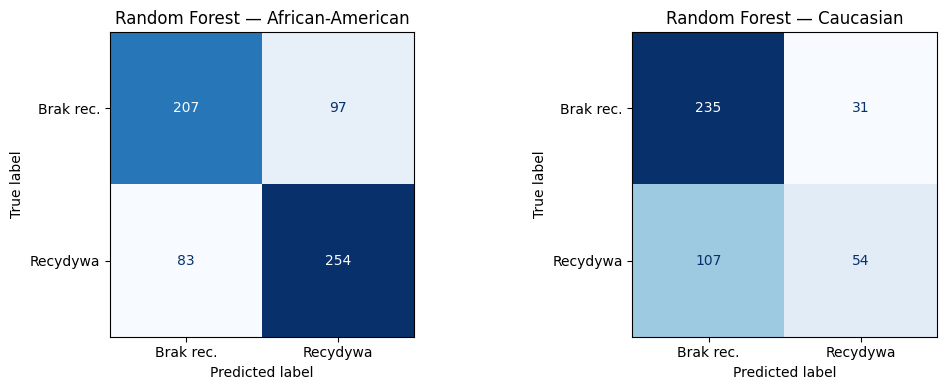

  Sex flip — odsetek zmienionych decyzji: 0.0834
  Wszyscy jako African-American pred_rate: 0.4186
  Wszyscy jako Caucasian pred_rate:        0.3223

  AdaBoost
  Demographic Parity Diff : 0.2205
  Equal Opportunity Diff  : 0.2305
  Equalized Odds Diff     : 0.2305

Metryki per grupa rasowa:
                     accuracy        f1       TPR       FPR  pred_rate
sensitive_feature_0                                                   
African-American     0.680187  0.682171  0.652819  0.289474   0.480499
Caucasian            0.681499  0.500000  0.422360  0.161654   0.259953

Roznice miedzy grupami:
accuracy     0.001312
f1           0.182171
TPR          0.230459
FPR          0.127820
pred_rate    0.220546

FPR/FNR/TPR per rasa:
  African-American: {'TPR': np.float64(0.6528189910979229), 'FPR': np.float64(0.2894736842105263), 'FNR': np.float64(0.34718100890207715), 'Accuracy': np.float64(0.6801872074882995)}
  Caucasian: {'TPR': np.float64(0.422360248447205), 'FPR': np.float64(0.1616541353

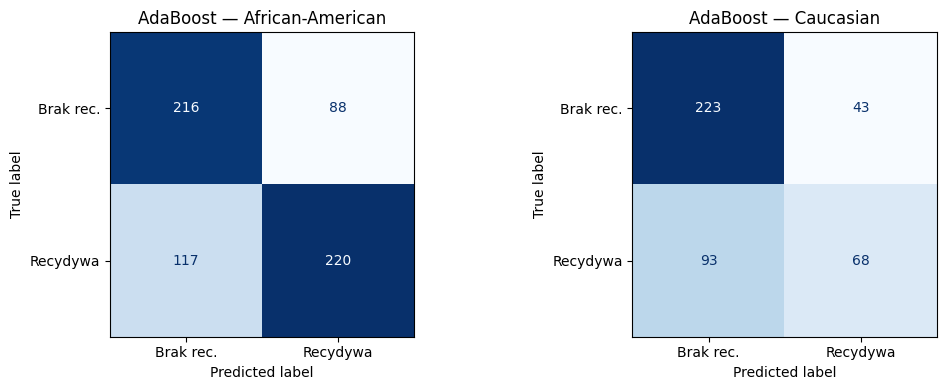

  Sex flip — odsetek zmienionych decyzji: 0.0996
  Wszyscy jako African-American pred_rate: 0.3717
  Wszyscy jako Caucasian pred_rate:        0.3717

  XGBoost
  Demographic Parity Diff : 0.2666
  Equal Opportunity Diff  : 0.2952
  Equalized Odds Diff     : 0.2952

Metryki per grupa rasowa:
                     accuracy        f1       TPR       FPR  pred_rate
sensitive_feature_0                                                   
African-American     0.717629  0.731055  0.729970  0.296053   0.524181
Caucasian            0.693208  0.516605  0.434783  0.150376   0.257611

Roznice miedzy grupami:
accuracy     0.024420
f1           0.214450
TPR          0.295188
FPR          0.145677
pred_rate    0.266570

FPR/FNR/TPR per rasa:
  African-American: {'TPR': np.float64(0.7299703264094956), 'FPR': np.float64(0.29605263157894735), 'FNR': np.float64(0.27002967359050445), 'Accuracy': np.float64(0.717628705148206)}
  Caucasian: {'TPR': np.float64(0.43478260869565216), 'FPR': np.float64(0.150375939

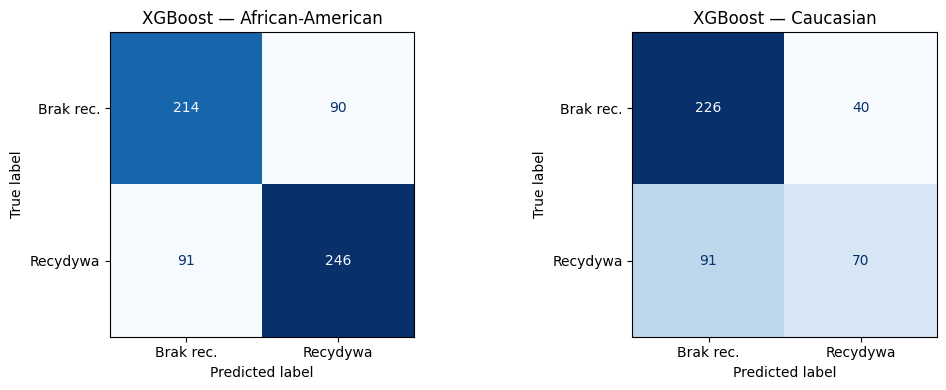

  Sex flip — odsetek zmienionych decyzji: 0.0486
  Wszyscy jako African-American pred_rate: 0.3984
  Wszyscy jako Caucasian pred_rate:        0.3870


In [32]:
_fairness_results = []
for name, m in best_models.items():
    r = run_fairness_analysis(m, name, X_test, y_test, sex_col_idx, race_col_indices)
    _fairness_results.append(r)


In [33]:
_fairness_df = pd.DataFrame(_fairness_results).set_index("Model")
print("\nZbiorcze metryki fairness:")
print(_fairness_df.to_string())
_fairness_df



Zbiorcze metryki fairness:
                   DP      EO   EOdds
Model                                
Random Forest  0.3485  0.4183  0.4183
AdaBoost       0.2205  0.2305  0.2305
XGBoost        0.2666  0.2952  0.2952


,DP,EO,EOdds
Model,,,
Random Forest,0.3485,0.4183,0.4183
AdaBoost,0.2205,0.2305,0.2305
XGBoost,0.2666,0.2952,0.2952


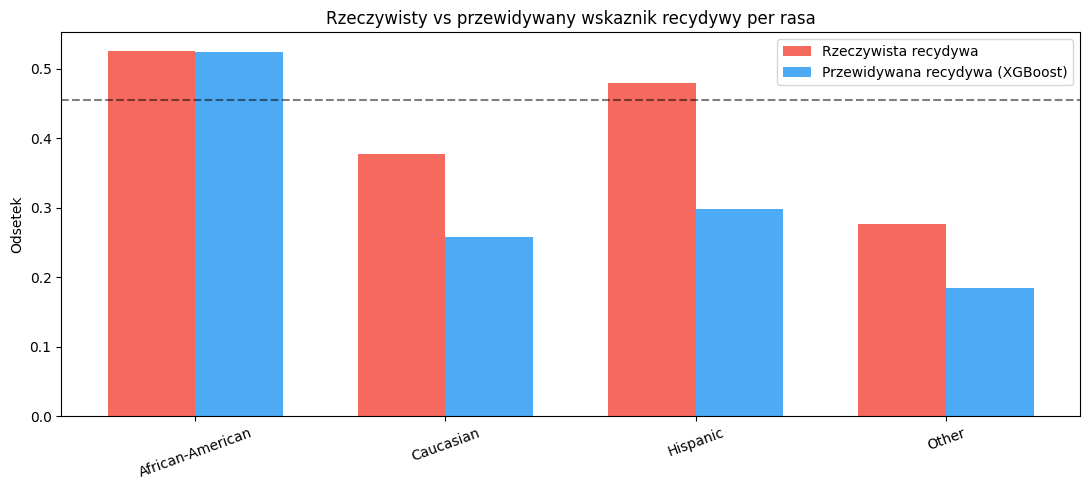

In [34]:
race_recid_real = {}
race_recid_pred = {}

for race in ["African-American", "Caucasian", "Hispanic", "Other", "Asian", "Native American"]:
    col = f"race_{race}"
    if col not in feature_cols:
        continue
    mask = X_test[:, race_col_indices[col]] == 1
    if mask.sum() < 10:
        continue
    race_recid_real[race] = y_test[mask].mean()
    race_recid_pred[race] = y_pred_baseline[mask].mean()

races = list(race_recid_real.keys())
x = np.arange(len(races))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, [race_recid_real[r] for r in races], width,
       label="Rzeczywista recydywa", color="#F44336", alpha=0.8)
ax.bar(x + width/2, [race_recid_pred[r] for r in races], width,
       label="Przewidywana recydywa (XGBoost)", color="#2196F3", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20)
ax.set_ylabel("Odsetek")
ax.set_title("Rzeczywisty vs przewidywany wskaznik recydywy per rasa")
ax.legend()
ax.axhline(y_test.mean(), color="black", linestyle="--", alpha=0.5, label="srednia")
plt.tight_layout()
plt.show()


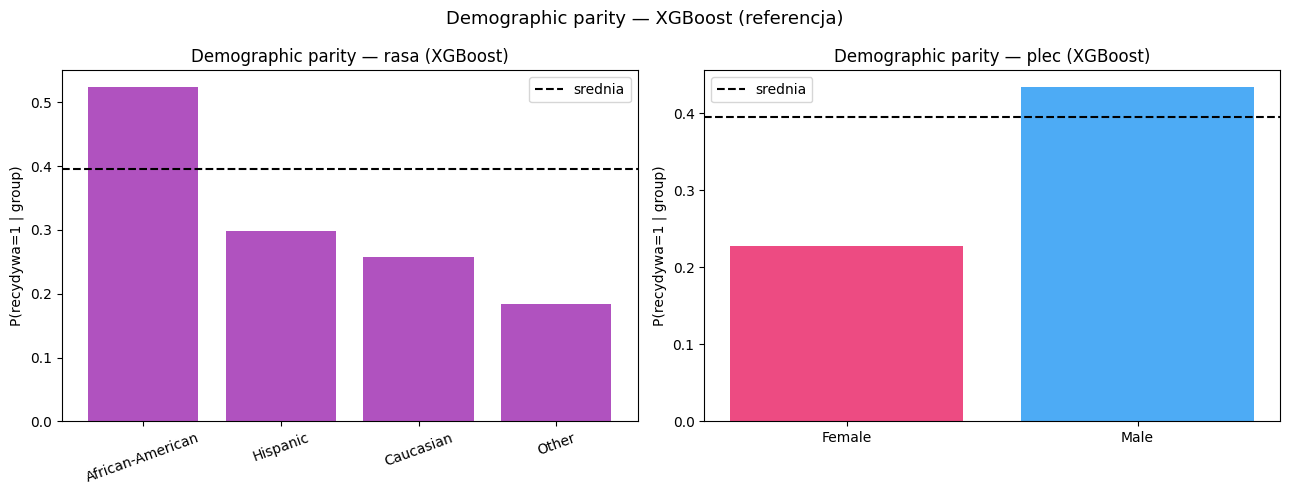

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
pred_rates_race = pd.Series(race_recid_pred).sort_values(ascending=False)
ax.bar(pred_rates_race.index, pred_rates_race.values, color="#9C27B0", alpha=0.8)
ax.axhline(y_pred_baseline.mean(), color="black", linestyle="--", label="srednia")
ax.set_title("Demographic parity — rasa (XGBoost)")
ax.set_ylabel("P(recydywa=1 | group)")
ax.tick_params(axis="x", rotation=20)
ax.legend()

ax = axes[1]
for sex_val, label, color in [(0, "Female", "#E91E63"), (1, "Male", "#2196F3")]:
    mask = X_test[:, sex_col_idx] == sex_val
    rate = y_pred_baseline[mask].mean()
    ax.bar(label, rate, color=color, alpha=0.8)
ax.axhline(y_pred_baseline.mean(), color="black", linestyle="--", label="srednia")
ax.set_title("Demographic parity — plec (XGBoost)")
ax.set_ylabel("P(recydywa=1 | group)")
ax.legend()

plt.suptitle("Demographic parity — XGBoost (referencja)", fontsize=13)
plt.tight_layout()
plt.show()
